#### Name: Jon Stowers

# PHYS 230 Lab Assignment 10

### Wednesday, February 25, 2026: Chapter 5.10-5.12
- Evaluating derivatives in python 
- Automatic Differentiation (& Interpolation)

***Don't forget to include comments in your code and a final markdown explanation at the end of each problem.***

In [37]:
# put all import statements here
import numpy as np
import math
import matplotlib.pyplot as plt

## Derivatives with front, back, and central difference (25 pts)

Let's evaluate the derivative of: 

$$ f(x) = \frac{1-\cos x}{x^2} $$

I don't want to do this by hand, so let's do it computationally. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define the function `f(x)` that returns the function $f(x)$ from above. 

In [3]:
def f(x):
    return (1-math.cos(x)) / x**2

#### Step 2: Define functions that call on your function from step 1 to calculate the front, back, and central difference first derivatives of $f(x)$ at a specific location $x$. 

In [4]:
def forwarddiff(f,x,h):
    return (f(x+h)-f(x))/h

def backwarddiff(f,x,h):
    return (f(x)-f(x-h))/h

def centraldiff(f,x,h):
    return (f(x+(h/2))-f(x-(h/2)))/h

#### Step 3: Evaluate the derivative using the three different approximations using the appropriate value of $h$ for each method evaluated from $x = 0.004$ to $x = \frac{\pi}{2}$ - let's do 20 calculations. 

In [11]:
Ncalcs = 20
a = 0.004
b = 0.5*math.pi

hfb = 1e-8 #appropriate value of h for forward and backward derivatives
hc = 1e-5 #appropriate value of h for central derivative


xvals = np.linspace(a,b,Ncalcs)

fdvals = np.zeros(Ncalcs)
bdvals = np.zeros(Ncalcs)
cdvals = np.zeros(Ncalcs)

for i in range(Ncalcs):
    fdvals[i] = forwarddiff(f,xvals[i],hfb)
    bdvals[i] = backwarddiff(f,xvals[i],hfb)
    cdvals[i] = centraldiff(f,xvals[i],hc)



print("x-value             forward diff           backward diff        central diff")
rowf = "{0:1.16f} {1:1.16f} {2:1.16f} {3:1.16f}" 
for i in range(Ncalcs):
    print(rowf.format(xvals[i],fdvals[i],bdvals[i],cdvals[i]))








x-value             forward diff           backward diff        central diff
0.0040000000000000 0.0000415223411210 -0.0007212619390629 -0.0003336258658226
0.0864629645681525 -0.0072017447561024 -0.0072004124884728 -0.0072016567431721
0.1689259291363049 -0.0140503386703017 -0.0140503775281076 -0.0140504008483422
0.2513888937044574 -0.0208609296503681 -0.0208609574059437 -0.0208609633345347
0.3338518582726098 -0.0276148326427972 -0.0276148492961426 -0.0276148813205257
0.4163148228407623 -0.0342939232567119 -0.0342938732966758 -0.0342938977826446
0.4987777874089148 -0.0408799882833932 -0.0408800437945445 -0.0408800281237465
0.5812407519770671 -0.0473556360791605 -0.0473556360791605 -0.0473556252822416
0.6637037165452196 -0.0537034472447573 -0.0537034527958724 -0.0537034430259098
0.7461666811133721 -0.0599066962703176 -0.0599067018214328 -0.0599066982687191
0.8286296456815245 -0.0659491294907610 -0.0659491405929913 -0.0659491308729887
0.9110926102496770 -0.0718150594547495 -0.0718150594547

#### Step 4: Determine the equation for the derivative (by hand and then type in below this cell as markdown). Computationally calculate the true value of the derivative at the range of values from step 3 and compare to your calculated values. Explain your results in a markdown cell. 

In [27]:
def fprime(x):
    return (x**2*math.sin(x)+2*x*math.cos(x)-2*x)/(x**4)
truevals = np.zeros(Ncalcs)
for i in range(Ncalcs):
    truevals[i] = fprime(xvals[i])


print("x-value             true values          forward diff        fdiff error         backward diff        bdiff error       central diff        cdiff error")
rowf = "{0:1.16f} {1:1.16f} {2:1.16f} {3:1.16f} {4:1.16f} {5:1.16f} {6:1.16f} {7:1.16f} " 
for i in range(Ncalcs):
    print(rowf.format(xvals[i],truevals[i],fdvals[i],abs(fdvals[i]-truevals[i]),bdvals[i],abs(bdvals[i]-truevals[i]),cdvals[i],abs(cdvals[i]-truevals[i])))



x-value             true values          forward diff        fdiff error         backward diff        bdiff error       central diff        cdiff error
0.0040000000000000 -0.0003333311816671 0.0000415223411210 0.0003748535227881 -0.0007212619390629 0.0003879307573958 -0.0003336258658226 0.0000002946841555 
0.0864629645681525 -0.0072016567463153 -0.0072017447561024 0.0000000880097871 -0.0072004124884728 0.0000012442578425 -0.0072016567431721 0.0000000000031432 
0.1689259291363049 -0.0140504008603943 -0.0140503386703017 0.0000000621900926 -0.0140503775281076 0.0000000233322867 -0.0140504008483422 0.0000000000120521 
0.2513888937044574 -0.0208609633668813 -0.0208609296503681 0.0000000337165132 -0.0208609574059437 0.0000000059609376 -0.0208609633345347 0.0000000000323467 
0.3338518582726098 -0.0276148812914274 -0.0276148326427972 0.0000000486486302 -0.0276148492961426 0.0000000319952848 -0.0276148813205257 0.0000000000290983 
0.4163148228407623 -0.0342938977411378 -0.0342939232567119 0.000

$f'(x) = \frac{x^2\sin{x}+2x\cos{x}-2x}{x^4}$

As predicted from using hopefully-optimal values of $h$, the errors are all quite low. The central differentiation has the lowest error, also as predicted.

#### Step 5: Evalute the derivative using the three approximations with a value of $h=10^{-6}$. Compare (computationally and in markdown) the values with each other and the true value. 

In [26]:
newh = 1e-6

newfdvals = np.zeros(Ncalcs)
newbdvals = np.zeros(Ncalcs)
newcdvals = np.zeros(Ncalcs)

for i in range(Ncalcs):
    newfdvals[i] = forwarddiff(f,xvals[i],newh)
    newbdvals[i] = backwarddiff(f,xvals[i],newh)
    newcdvals[i] = centraldiff(f,xvals[i],newh)

print("x-value             true values          forward diff        fdiff error         backward diff        bdiff error       central diff        cdiff error")
rowf = "{0:1.16f} {1:1.16f} {2:1.16f} {3:1.16f} {4:1.16f} {5:1.16f} {6:1.16f} {7:1.16f} " 
for i in range(Ncalcs):
    print(rowf.format(xvals[i],truevals[i],newfdvals[i],abs(newfdvals[i]-truevals[i]),newbdvals[i],abs(newbdvals[i]-truevals[i]),newcdvals[i],abs(newcdvals[i]-truevals[i])))


x-value             true values          forward diff        fdiff error         backward diff        bdiff error       central diff        cdiff error
0.0040000000000000 -0.0003333311816671 -0.0003299469031326 0.0000033842785345 -0.0003359194034047 0.0000025882217376 -0.0003329334585800 0.0000003977230871 
0.0864629645681525 -0.0072016567463153 -0.0072017040109174 0.0000000472646021 -0.0072016125285401 0.0000000442177752 -0.0072016508867456 0.0000000058595697 
0.1689259291363049 -0.0140504008603943 -0.0140504414769538 0.0000000406165595 -0.0140503587098273 0.0000000421505670 -0.0140504018419918 0.0000000009815975 
0.2513888937044574 -0.0208609633668813 -0.0208610037577550 0.0000000403908737 -0.0208609231555634 0.0000000402113179 -0.0208609627350143 0.0000000006318671 
0.3338518582726098 -0.0276148812914274 -0.0276149217937061 0.0000000405022787 -0.0276148405253807 0.0000000407660467 -0.0276148813260768 0.0000000000346494 
0.4163148228407623 -0.0342938977411378 -0.0342939379116558 0.00

Using sub-optimal values for $h$ predictably increases the errors for all three differentiation methods (because it is too low for forward and backward and too high for central) but the error is only a little bit larger. The value of $h$ would have to be several orders of magnitude off of the optimal value for the value to be very inaccurate.

## Second derivative (22 pts)

Let's take the second derivative of the function from above. 

*Note: don't forget to put brief comments in your code*

#### Step 1: Define functions that call on your function from step 1 above to calculate the second derivative of $f(x)$ at a specific location $x$ using central difference. 

In [28]:
def dfxplus(f,x,h): #f'(x+(h/2))
    return centraldiff(f,(x+(h/2)),h)
def dfxminus(f,x,h): #f'(x-(h/2))
    return centraldiff(f,(x-(h/2)),h)
def d2fx(dxplus,dxminus,h): #calculates second derivative using the two prior functions
    return (dxplus-dxminus)/h

#### Step 2: Evalute the second derivative at $x = 0.004$ using a range of $h$ values from `1e-1` to `1e-12`. 

In [29]:
x = 0.004

h = []
for i in range(1,13):
    h.append(10**(-i))

d2values = np.zeros(len(h))
for i in range(len(h)):
    d2values[i] = d2fx(dfxplus(f,x,h[i]),dfxminus(f,x,h[i]),h[i])

print('h        second derivative')
rowf = '{0:1.0e} {1:1.16f}'
for i in range(len(h)):
    print(rowf.format(h[i],d2values[i]))



h        second derivative
1e-01 -0.0833052937077472
1e-02 -0.0833327690674679
1e-03 -0.0833309349856926
1e-04 -0.0832469149170123
1e-05 -0.0639432951032859
1e-06 5.9723892498197984
1e-07 -49.5381513587744848
1e-08 76278.4280183836963261
1e-09 -62505.5562863960949471
1e-10 -66613.3814775093924254
1e-11 -555111.5123125782702118
1e-12 -111022302.4625156521797180


#### Step 3: Determine the equation for the derivative (by hand/WolframAlpha and then type in below this cell as markdown). Calculate the true value of the derivative at $x = 0.004$.  

$f''(x) = -\frac{4x\sin{x}+(6-x^2)\cos{x}-6}{x^4}$

In [30]:
def trued2fx(x):
    return -1*(4*x*math.sin(x)+(6-x**2)*math.cos(x)-6)/(x**4)

x = 0.004
truevald2fx = trued2fx(x)
print(truevald2fx)


-0.08333264633897385


#### Step 4: Computationally compare your calculated answer to the true value for each $h$ value. Include a markdown explaining the process and result.

In [36]:

d2errors = np.copy(d2values)
for i in range(len(d2errors)):
    d2errors[i] = abs(d2values[i]-truevald2fx) #populates errors


print('true value           h        second derivative      error')
rowf = '{0:1.16f} {1:1.0e} {2:1.16f} {3:1.16f}'
for i in range(len(h)):
    print(rowf.format(truevald2fx,h[i],d2values[i],d2errors[i]))



true value           h        second derivative      error
-0.0833326463389738 1e-01 -0.0833052937077472 0.0000273526312266
-0.0833326463389738 1e-02 -0.0833327690674679 0.0000001227284940
-0.0833326463389738 1e-03 -0.0833309349856926 0.0000017113532813
-0.0833326463389738 1e-04 -0.0832469149170123 0.0000857314219615
-0.0833326463389738 1e-05 -0.0639432951032859 0.0193893512356880
-0.0833326463389738 1e-06 5.9723892498197984 6.0557218961587722
-0.0833326463389738 1e-07 -49.5381513587744848 49.4548187124355110
-0.0833326463389738 1e-08 76278.4280183836963261 76278.5113510300288908
-0.0833326463389738 1e-09 -62505.5562863960949471 62505.4729537497551064
-0.0833326463389738 1e-10 -66613.3814775093924254 66613.2981448630598607
-0.0833326463389738 1e-11 -555111.5123125782702118 555111.4289799319813028
-0.0833326463389738 1e-12 -111022302.4625156521797180 111022302.3791830092668533


I calculated the error by subtracting the treue value from each calculated value. We would expect the lowest error to be at $h = 10^{-4}$, which is what we said to be optimal for second derivatives using central differentiation, but our lowest value was actually at $h=10^{-2}$.

## Automatic Differentiation 

Let's use the method of automatic differentation to determine the value for both the function 

$f(x) = x+\tan(\cos^2x+\sin^2x)$ 

and its derivative at $x = 0$ (or at $t = 0$ as described in class). Do so using the following steps. 

a) Write a Python function `f(x)` to compute the function value and derivative of a list $x$ using automatic differentiation. [Hint: you will need a few additional functions as well -> look at the class notebook example]

b) Make a plot of the function $f(x)$ vs. $x$ over the range of $-\pi$ to $\pi$ that you will be able to compare with your results in part c. 

c) Use your function determine the function and dervative values at $x = 0$ ($t=0$). Remember, that your list should be entered as `[t,1]`. How do you results compare with part b? Add a markdown cell to explain your process and compare your answer with your graph from part b. 


Hint: If you program is taking a long time to run, then you are probably doing the calculation the wrong way. It should only take a second or two to finish.

In [38]:
# part a
def mult(x,c):
    vx,dx = x
    return [c*vx,c*dx]

def sin(x):
    vx,dx = x
    return [math.sin(vx),math.cos(vx)*dx]

def cos(x):
    vx,dx = x
    return [math.cos(vx),-1*math.sin(vx)*dx]

def tan(x):
    vx,dx = x
    return [math.tan(vx),(1/math.cos(vx))**2*dx]

def power(x,c):
    vx,dx = x
    return [vx**c, c*vx**(c-1)*dx]

def add(x,y):
    vx,dx = x
    vy,dy = y
    return [vx+vy,dx+dy]


def f(x):
    u1 = mult(x,1)
    u2 = cos(x)
    u3 = sin(x)
    u4 = power(u2,2)
    u5 = power(u3,2)
    u6 = add(u4+u5)
    u7 = tan(u6)
    u8 = add(u1,u7)
    return u8



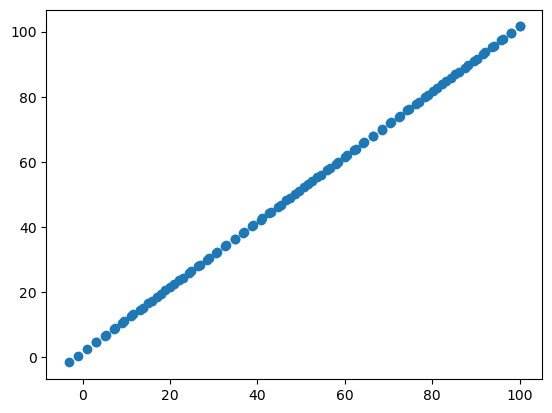

In [44]:
# part b

def function(x):
    return x + np.tan((np.cos(x))**2 + (np.sin(x))**2)


xvals = np.linspace([-math.pi,math.pi],100)






plt.scatter(xvals,function(xvals))
plt.show()



Here I ran out of time, so I had to turn in the lab early.

In [ ]:
# part c